In [7]:
import pandas as pd
import matplotlib.pyplot as plt

import scipy.sparse as sp
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.svm import LinearSVC
from sklearn.model_selection import GridSearchCV
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, f1_score
from sklearn.model_selection import train_test_split

In [8]:
# Load the train and test data
train_df = pd.read_csv("/work/outputs/train.csv")
test_df = pd.read_csv("/work/outputs/test.csv")

emoji_to_sentiment = {
    "heart_eyes": "positive",
    "blush": "positive",
    "grin": "positive",
    "relaxed": "positive",
    "yum": "positive",
    "wink": "positive",
    "smirk": "positive",

    "sob": "negative",
    "weary": "negative",
    "flushed": "negative",  # depends, but usually stress/embarrassment
}

train_df["sentiment_label"] = train_df["label"].map(emoji_to_sentiment)
test_df["sentiment_label"] = test_df["label"].map(emoji_to_sentiment)


text_col = "clean_text"

brand_cols = [c for c in train_df.columns if c.startswith("brand_")]
numeric_cols = [
    "char_count",
    "word_count",
    "has_link",
    "has_mention",
    "has_hashtag",
    "is_retweet",
    "exclamation_count",
    "question_count",
    "sent_compound"
] + brand_cols

# separate by text and numeric features
X_train_text = train_df[text_col]
X_test_text = test_df[text_col]

X_train_num = train_df[numeric_cols]
X_test_num = test_df[numeric_cols]

# Labels
y_train = train_df["sentiment_label"]
y_test = test_df["sentiment_label"]

In [18]:
train_df

,text,label,clean_text,char_count,word_count,has_link,has_mention,has_hashtag,is_retweet,exclamation_count,...,brand_subway,brand_dominos,brand_dunkindonuts,brand_pizzahut,brand_walmart,brand_burger_king,brand_chipotle,brand_five_guys,brand_mention_total,sentiment_label
0,@Cobysavage17 bet you I'll knock yo ass out,sob,bet you i'll knock yo ass out,44,7,False,True,False,False,0,...,0,0,0,0,0,0,0,0,0,negative
1,@mollyralvis bet she came home just to see me,smirk,bet she came home just to see me,46,8,False,True,False,False,0,...,0,0,0,0,0,0,0,0,0,positive
2,I think I'm getting my sugar rush from the Sta...,flushed,i think i'm getting my sugar rush from the sta...,66,12,False,False,False,False,0,...,0,0,0,0,0,0,0,0,1,negative
3,@jackgilinsky @ShawnMendes I wish I was there ...,sob,i wish i was there but i bet he did amazing im...,90,16,False,True,False,False,1,...,0,0,0,0,0,0,0,0,0,negative
4,RT @_MeganLambert: I can't wait until I can dr...,yum,i can't wait until i can drive bcos that means...,108,18,False,True,False,True,0,...,0,0,0,0,0,0,0,0,1,positive
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
157726,I was so busy at work today that I didn't even...,sob,i was so busy at work today that i didn't even...,126,26,False,False,False,False,0,...,0,0,0,0,0,0,0,0,1,negative
157727,I bet you missed me bitch https://t.co/vEdTft...,yum,i bet you missed me bitch,50,6,True,False,False,False,0,...,0,0,0,0,0,0,0,0,0,positive
157728,Bet anything my homegirl bail on me tonight ag...,weary,bet anything my homegirl bail on me tonight ag...,92,17,False,False,False,False,0,...,0,0,0,0,0,0,0,0,0,negative
157729,RT @ItsFoodPorn: Starbucks https://t.co/IfJP1...,yum,starbucks,51,1,True,True,False,True,0,...,0,0,0,0,0,0,0,0,1,positive


In [10]:
# Encoding and Vectorization
# Encode labels
le = LabelEncoder()
y_train = le.fit_transform(y_train)
y_test = le.transform(y_test)

# TF-IDF
vectorizer = TfidfVectorizer(
    max_features=15000,
    ngram_range=(1, 2),
    min_df=2,
    max_df=0.95,
    sublinear_tf=True,
    stop_words=None
)

X_train_text_vec = vectorizer.fit_transform(X_train_text)
X_test_text_vec = vectorizer.transform(X_test_text)

# Scale numeric features so that features with a large range do not dominate those with a small range
scaler = StandardScaler(with_mean=False)
X_train_num_scaled = scaler.fit_transform(X_train_num)
X_test_num_scaled = scaler.transform(X_test_num)

# Convert numeric features to sparse matrices
X_train_num_sparse = sp.csr_matrix(X_train_num_scaled)
X_test_num_sparse = sp.csr_matrix(X_test_num_scaled)

# Combine text with numeric features
X_train_final = sp.hstack([X_train_text_vec, X_train_num_sparse])
X_test_final = sp.hstack([X_test_text_vec, X_test_num_sparse])

In [12]:
# param_grid will be the grid of parameters to search over.
# C is the regularization parameter. 
#   Small C means STRONGER regularization -> simpler model that reduces overfitting (may risk underfitting though)
#   Large C means WEAKER regularization -> more complicated model (may risk overfitting)
# class_weight is used to handle class imbalance. 
#  Need this because the 10 labels/emojis don't have equal number of tweets
# loss is the loss function we use to penalize errors. squared_hinge penalizes errors more


# grid search just finds the best combination of parameters.
# use f1_macro for performance eval because we want performance across all emojis, not just the biggest class.
#.    computes F1 for each class -> averages them equally. better than pure accuracy when class sizes differ.


def run_svm_experiment(X_train_final, X_test_final, y_train, y_test, le, model_name):
    svm_model = LinearSVC(max_iter=5000)


    # parameters = {
    # 'C': [0.1, 1, 10],
    # 'kernel': ['linear', 'rbf'],
    # 'gamma': ['scale', 'auto']
    # }

    param_grid = {
        "C": [0.01, 0.1, 1],
        "class_weight": [None, "balanced"]
    }

    grid_search = GridSearchCV(
        estimator=svm_model,
        param_grid=param_grid,
        cv=3,
        scoring={
            "f1_macro": "f1_macro",
            "accuracy": "accuracy"
        },
        refit="f1_macro",
        n_jobs=-1,
        verbose=2,
        return_train_score=True
    )

    # Stratified subset for faster tuning
    X_small, _, y_small, _ = train_test_split(
        X_train_final,
        y_train,
        train_size=60000,
        random_state=42,
        stratify=y_train
    )

    # Fit grid search on subset
    grid_search.fit(X_small, y_small)

    # Best fitted model from grid search (already trained on X_small)
    best_svm = grid_search.best_estimator_

    # Predict on test set using the fitted best model
    y_pred = best_svm.predict(X_test_final)

    test_acc = accuracy_score(y_test, y_pred)

    print(f"\n===== {model_name} =====")
    print("Best Parameters:", grid_search.best_params_)
    print("Best CV Macro F1:", grid_search.best_score_)
    print("\nTest Accuracy:", f"{test_acc:.4f}")
    print("\nClassification Report:\n")
    print(classification_report(
        y_test,
        y_pred,
        target_names=[str(c) for c in le.classes_]
    ))
    print("\nConfusion Matrix:\n")
    print(confusion_matrix(y_test, y_pred))

    return {
        "model_name": model_name,
        "grid_search": grid_search,
        "best_model": best_svm,
        "y_pred": y_pred,
        "test_accuracy": test_acc,
        "test_macro_f1": f1_score(y_test, y_pred, average="macro")
    }

In [14]:
all_features_results = run_svm_experiment(
    X_train_final,
    X_test_final,
    y_train,
    y_test,
    le,
    model_name="SVM - TFIDF + All Features"
)

Fitting 3 folds for each of 6 candidates, totalling 18 fits
/root/venv/lib/python3.11/site-packages/sklearn/svm/_classes.py:32: FutureWarning: The default value of `dual` will change from `True` to `'auto'` in 1.5. Set the value of `dual` explicitly to suppress the warning.
  warnings.warn(
/root/venv/lib/python3.11/site-packages/sklearn/svm/_classes.py:32: FutureWarning: The default value of `dual` will change from `True` to `'auto'` in 1.5. Set the value of `dual` explicitly to suppress the warning.
  warnings.warn(
[CV] END ..........................C=0.01, class_weight=None; total time=   6.4s
/root/venv/lib/python3.11/site-packages/sklearn/svm/_classes.py:32: FutureWarning: The default value of `dual` will change from `True` to `'auto'` in 1.5. Set the value of `dual` explicitly to suppress the warning.
  warnings.warn(
[CV] END ..........................C=0.01, class_weight=None; total time=   3.8s
/root/venv/lib/python3.11/site-packages/sklearn/svm/_classes.py:32: FutureWarning:

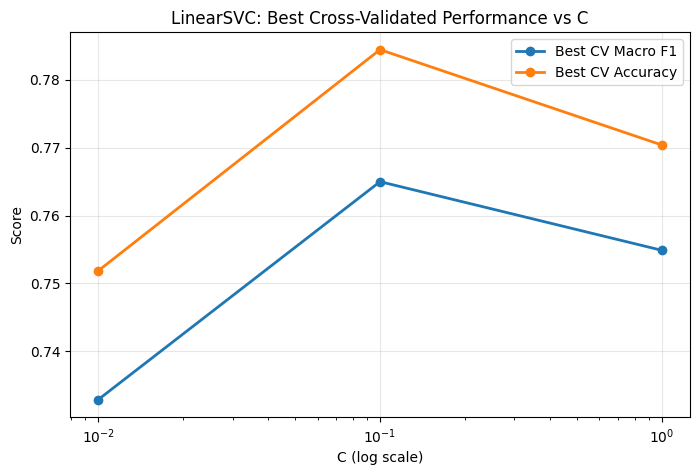

In [18]:
# GRAPH 1: Best validation Macro F1 and Accuracy by C
# For each C, keep the best score across class_weight options
# Shows the best accuracy and f1 at each C

results = pd.DataFrame(all_features_results["grid_search"].cv_results_)

# Make C numeric so sorting/plotting works properly
results["param_C"] = results["param_C"].astype(float)

best_f1_per_C = (results.groupby("param_C", as_index=False)["mean_test_f1_macro"]
    .max()
    .sort_values("param_C")
)

best_acc_per_C = (results.groupby("param_C", as_index=False)["mean_test_accuracy"]
    .max()
    .sort_values("param_C")
)

plt.figure(figsize=(8, 5))
plt.plot(
    best_f1_per_C["param_C"],
    best_f1_per_C["mean_test_f1_macro"],
    marker="o",
    linewidth=2,
    label="Best CV Macro F1"
)
plt.plot(
    best_acc_per_C["param_C"],
    best_acc_per_C["mean_test_accuracy"],
    marker="o",
    linewidth=2,
    label="Best CV Accuracy"
)
plt.xscale("log")
plt.xlabel("C (log scale)")
plt.ylabel("Score")
plt.title("LinearSVC: Best Cross-Validated Performance vs C")
plt.grid(True, alpha=0.3)
plt.legend()
plt.show()

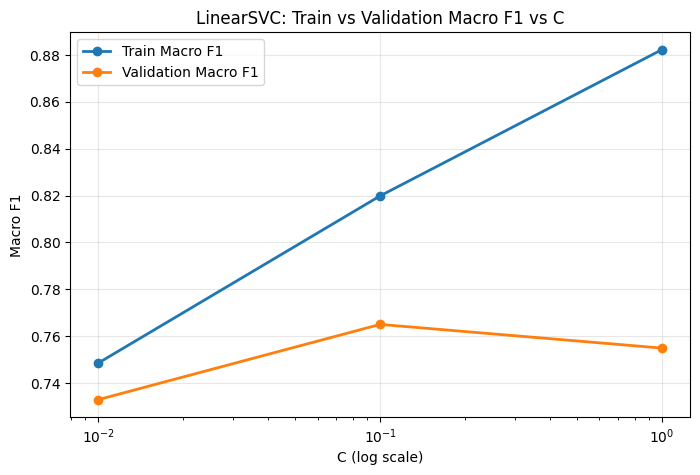

In [20]:
# GRAPH 2: Train vs Validation Macro F1 by C
# For each C, pick the row with the best validation macro F1
# Then plot that row's train and validation macro F1
# This is used to see if the model is under/overfitting

best_rows = results.loc[
    results.groupby("param_C")["mean_test_f1_macro"].idxmax()
].copy()

best_rows["param_C"] = best_rows["param_C"].astype(float)
best_rows = best_rows.sort_values("param_C")

plt.figure(figsize=(8, 5))
plt.plot(
    best_rows["param_C"],
    best_rows["mean_train_f1_macro"],
    marker="o",
    linewidth=2,
    label="Train Macro F1"
)
plt.plot(
    best_rows["param_C"],
    best_rows["mean_test_f1_macro"],
    marker="o",
    linewidth=2,
    label="Validation Macro F1"
)
plt.xscale("log")
plt.xlabel("C (log scale)")
plt.ylabel("Macro F1")
plt.title("LinearSVC: Train vs Validation Macro F1 vs C")
plt.grid(True, alpha=0.3)
plt.legend()
plt.show()

In [24]:
# Instead of using all the features for the SVM, we can try just using the vectorized text. 
# Allows us to eee if the other features make a big difference in model performance.

X_train_text = train_df["clean_text"]
X_test_text = test_df["clean_text"]

y_train = train_df["sentiment_label"]
y_test = test_df["sentiment_label"]

# Encode labels
le = LabelEncoder()
y_train = le.fit_transform(y_train)
y_test = le.transform(y_test)

vectorizer = TfidfVectorizer(
    max_features=15000,
    ngram_range=(1, 2),
    min_df=2,
    max_df=0.95,
    sublinear_tf=True,
    stop_words=None
)

X_train_text_vec = vectorizer.fit_transform(X_train_text)
X_test_text_vec = vectorizer.transform(X_test_text)


text_only_results = run_svm_experiment(
    X_train_text_vec,   # ONLY text features
    X_test_text_vec,
    y_train,
    y_test,
    le,
    model_name="SVM - TFIDF Text Only"
)

Fitting 3 folds for each of 6 candidates, totalling 18 fits
/root/venv/lib/python3.11/site-packages/sklearn/svm/_classes.py:32: FutureWarning: The default value of `dual` will change from `True` to `'auto'` in 1.5. Set the value of `dual` explicitly to suppress the warning.
  warnings.warn(
/root/venv/lib/python3.11/site-packages/sklearn/svm/_classes.py:32: FutureWarning: The default value of `dual` will change from `True` to `'auto'` in 1.5. Set the value of `dual` explicitly to suppress the warning.
  warnings.warn(
[CV] END ..........................C=0.01, class_weight=None; total time=   0.2s
[CV] END ..........................C=0.01, class_weight=None; total time=   0.1s
/root/venv/lib/python3.11/site-packages/sklearn/svm/_classes.py:32: FutureWarning: The default value of `dual` will change from `True` to `'auto'` in 1.5. Set the value of `dual` explicitly to suppress the warning.
  warnings.warn(
/root/venv/lib/python3.11/site-packages/sklearn/svm/_classes.py:32: FutureWarning:

<a style='text-decoration:none;line-height:16px;display:flex;color:#5B5B62;padding:10px;justify-content:end;' href='https://deepnote.com?utm_source=created-in-deepnote-cell&projectId=62b91583-1382-466d-9446-3dc5e725c312' target="_blank">

Created in <span style='font-weight:600;margin-left:4px;'>Deepnote</span></a>